<a href="https://colab.research.google.com/github/sevvallkocc06/NeuroSense/blob/main/alzheimer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tmm import coh_tmm
import numpy as np

n_list = [1.5151, 0.1726+3.4218j, 1.330]
d_list = [float('inf'), 50, float('inf')]

aci_radyan = np.radians(75)

sonuc = coh_tmm('p', n_list, d_list, aci_radyan, 633)

print(sonuc['R'])

0.4634020618162416


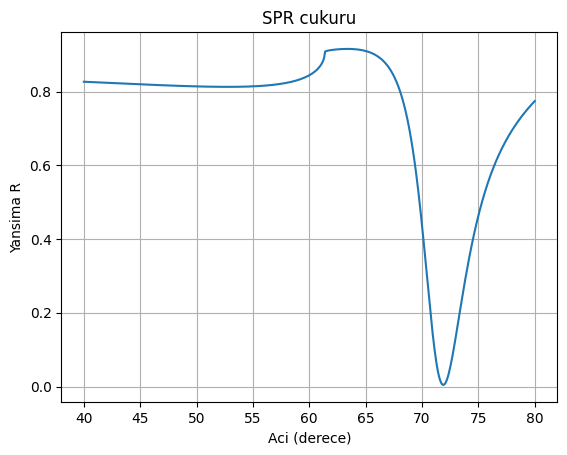

Cukurun dibi: 71.9 derece


In [ ]:
from tmm import coh_tmm
import numpy as np
import matplotlib.pyplot as plt

# Katmanlar: prizma / altin / analit
n_list = [1.5151, 0.1726 + 3.4218j, 1.330]
d_list = [float('inf'), 50, float('inf')]

# 40-80 derece arasi 500 aci tara
acilar = np.linspace(40, 80, 500)
R_listesi = []

for aci in acilar:
    aci_radyan = np.radians(aci)
    sonuc = coh_tmm('p', n_list, d_list, aci_radyan, 633)
    R_listesi.append(sonuc['R'])

# Cizdir
plt.plot(acilar, R_listesi)
plt.xlabel('Aci (derece)')
plt.ylabel('Yansima R')
plt.title('SPR cukuru')
plt.grid(True)
plt.show()

# Cukurun dibi
en_dusuk = np.argmin(R_listesi)
print("Cukurun dibi:", round(acilar[en_dusuk], 2), "derece")

Protein yokken cukur: 71.904 derece
Protein varken cukur: 73.267 derece
KAYMA: 1.363 derece


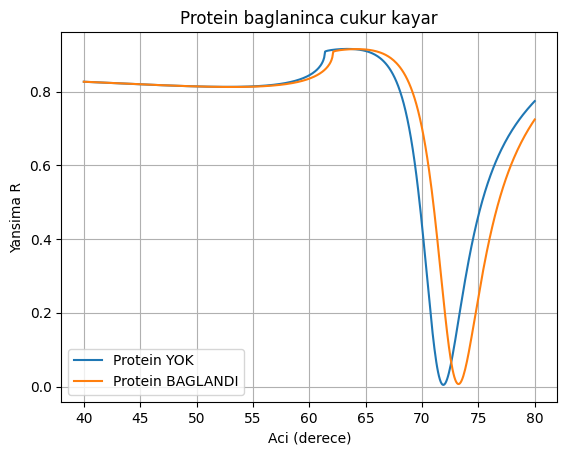

In [ ]:
from tmm import coh_tmm
import numpy as np
import matplotlib.pyplot as plt

#  Cukuru hesaplayan fonksiyon
# Ona bir analit indisi veriyoruz, o bize acilari ve R listesini geri veriyor.
def cukur_hesapla(analit_indisi):
    n_list = [1.5151, 0.1726 + 3.4218j, analit_indisi]
    d_list = [float('inf'), 50, float('inf')]
    acilar = np.linspace(40, 80, 500)
    R_listesi = []
    for aci in acilar:
        aci_radyan = np.radians(aci)
        sonuc = coh_tmm('p', n_list, d_list, aci_radyan, 633)
        R_listesi.append(sonuc['R'])
    return acilar, R_listesi

#  Fonksiyonu IKI kez cagir
acilar, R_protein_yok = cukur_hesapla(1.330)   # protein YOK
acilar, R_protein_var = cukur_hesapla(1.339)   # protein BAGLANDI

#  Her iki cukurun dibini bul, kaymayi olc
dip_yok = acilar[np.argmin(R_protein_yok)]
dip_var = acilar[np.argmin(R_protein_var)]
kayma = dip_var - dip_yok

print("Protein yokken cukur:", round(dip_yok, 3), "derece")
print("Protein varken cukur:", round(dip_var, 3), "derece")
print("KAYMA:", round(kayma, 3), "derece")

#  Ikisini birlikte cizdir
plt.plot(acilar, R_protein_yok, label='Protein YOK')
plt.plot(acilar, R_protein_var, label='Protein BAGLANDI')
plt.xlabel('Aci (derece)')
plt.ylabel('Yansima R')
plt.title('Protein baglaninca cukur kayar')
plt.legend()
plt.grid(True)
plt.show()

Grafensiz cukur: 71.9 derece
Grafenli cukur : 74.23 derece


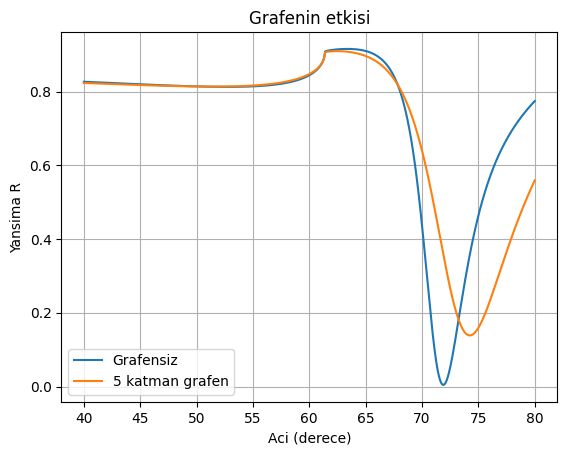

In [ ]:
from tmm import coh_tmm
import numpy as np
import matplotlib.pyplot as plt

# Grafenin ozellikleri
N_GRAFEN = 3.0 + 1.149j    # grafenin kirilma indisi (633 nm)
KALINLIK = 0.34            # tek grafen katmani = 0.34 nm

# Cukur fonksiyonu: grafen katman sayisini da soruyoruz
def cukur_hesapla(analit_indisi, grafen_katman=0):
    # Once grafensiz temel yigin:
    n_list = [1.5151, 0.1726 + 3.4218j]      # prizma, altin
    d_list = [float('inf'), 50]

    # Eger grafen isteniyorsa, araya ekle:
    if grafen_katman > 0:
        n_list.append(N_GRAFEN)
        d_list.append(grafen_katman * KALINLIK)   # N katman = N * 0.34 nm

    # En uste analiti ekle:
    n_list.append(analit_indisi)
    d_list.append(float('inf'))

    # Acilari tara, R biriktir (Adim 2/3 ile ayni)
    acilar = np.linspace(40, 80, 500)
    R_listesi = []
    for aci in acilar:
        sonuc = coh_tmm('p', n_list, d_list, np.radians(aci), 633)
        R_listesi.append(sonuc['R'])
    return acilar, R_listesi

#  Grafensiz vs 5 katman grafen (ikisi de protein yokken)
acilar, R_grafensiz = cukur_hesapla(1.330, grafen_katman=0)
acilar, R_grafenli  = cukur_hesapla(1.330, grafen_katman=5)

print("Grafensiz cukur:", round(acilar[np.argmin(R_grafensiz)], 2), "derece")
print("Grafenli cukur :", round(acilar[np.argmin(R_grafenli)], 2), "derece")

#  Cizdir
plt.plot(acilar, R_grafensiz, label='Grafensiz')
plt.plot(acilar, R_grafenli,  label='5 katman grafen')
plt.xlabel('Aci (derece)')
plt.ylabel('Yansima R')
plt.title('Grafenin etkisi')
plt.legend()
plt.grid(True)
plt.show()

Grafen katman: 0   Duyarlilik: 151.4 derece/RIU
Grafen katman: 1   Duyarlilik: 160.3 derece/RIU
Grafen katman: 2   Duyarlilik: 160.3 derece/RIU
Grafen katman: 3   Duyarlilik: 160.3 derece/RIU
Grafen katman: 4   Duyarlilik: 160.3 derece/RIU
Grafen katman: 5   Duyarlilik: 169.2 derece/RIU
Grafen katman: 6   Duyarlilik: 169.2 derece/RIU
Grafen katman: 7   Duyarlilik: 178.1 derece/RIU
Grafen katman: 8   Duyarlilik: 169.2 derece/RIU
Grafen katman: 9   Duyarlilik: 178.1 derece/RIU
Grafen katman: 10   Duyarlilik: 169.2 derece/RIU

EN IYI: 9 katman -> 178.1 derece/RIU


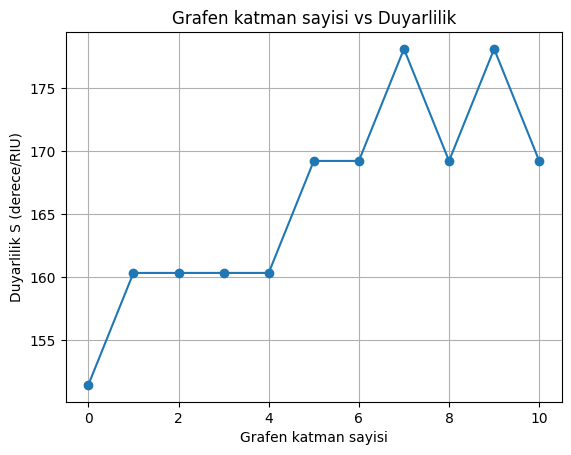

In [ ]:
from tmm import coh_tmm
import numpy as np
import matplotlib.pyplot as plt

N_GRAFEN = 3.0 + 1.149j
KALINLIK = 0.34

# Cukur fonksiyonu (Adim 4 ile ayni)
def cukur_hesapla(analit_indisi, grafen_katman=0):
    n_list = [1.5151, 0.1726 + 3.4218j]
    d_list = [float('inf'), 50]
    if grafen_katman > 0:
        n_list.append(N_GRAFEN)
        d_list.append(grafen_katman * KALINLIK)
    n_list.append(analit_indisi)
    d_list.append(float('inf'))
    acilar = np.linspace(40, 80, 500)
    R_listesi = []
    for aci in acilar:
        sonuc = coh_tmm('p', n_list, d_list, np.radians(aci), 633)
        R_listesi.append(sonuc['R'])
    return acilar, R_listesi

#  Bir katman sayisi icin duyarliligi hesapla (S = kayma / Δn)
def duyarlilik_hesapla(grafen_katman):
    dn = 1.339 - 1.330
    acilar, R_yok = cukur_hesapla(1.330, grafen_katman)   # protein yok
    _,      R_var = cukur_hesapla(1.339, grafen_katman)   # protein var
    dip_yok = acilar[np.argmin(R_yok)]
    dip_var = acilar[np.argmin(R_var)]
    kayma = dip_var - dip_yok
    return kayma / dn

#  0'dan 10'a kadar tara
katmanlar = range(0, 11)
duyarliliklar = []

for N in katmanlar:
    S = duyarlilik_hesapla(N)
    duyarliliklar.append(S)
    print("Grafen katman:", N, "  Duyarlilik:", round(S, 1), "derece/RIU")

#  En iyi katman sayisi
en_iyi = np.argmax(duyarliliklar)
print("\nEN IYI:", en_iyi, "katman ->", round(duyarliliklar[en_iyi], 1), "derece/RIU")

#  Cizdir
plt.plot(list(katmanlar), duyarliliklar, 'o-')
plt.xlabel('Grafen katman sayisi')
plt.ylabel('Duyarlilik S (derece/RIU)')
plt.title('Grafen katman sayisi vs Duyarlilik')
plt.grid(True)
plt.show()

Grafen katman: 0   Duyarlilik: 150.0 derece/RIU
Grafen katman: 1   Duyarlilik: 153.9 derece/RIU
Grafen katman: 2   Duyarlilik: 157.2 derece/RIU
Grafen katman: 3   Duyarlilik: 161.7 derece/RIU
Grafen katman: 4   Duyarlilik: 165.6 derece/RIU
Grafen katman: 5   Duyarlilik: 168.9 derece/RIU
Grafen katman: 6   Duyarlilik: 171.7 derece/RIU
Grafen katman: 7   Duyarlilik: 173.9 derece/RIU
Grafen katman: 8   Duyarlilik: 174.5 derece/RIU
Grafen katman: 9   Duyarlilik: 172.2 derece/RIU
Grafen katman: 10   Duyarlilik: 168.4 derece/RIU

EN IYI: 8 katman -> 174.5 derece/RIU


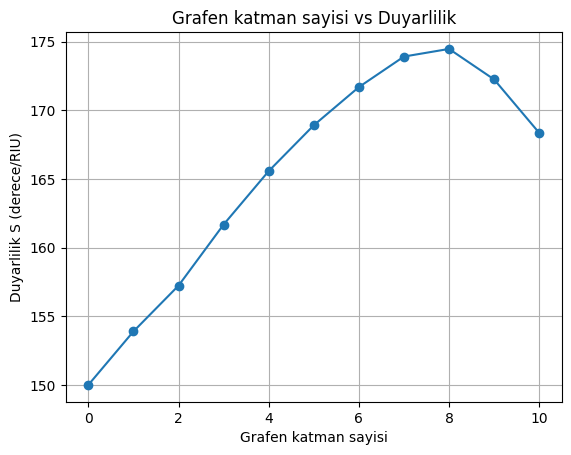

In [ ]:
from tmm import coh_tmm
import numpy as np
import matplotlib.pyplot as plt

N_GRAFEN = 3.0 + 1.149j
KALINLIK = 0.34

# Cukur fonksiyonu (Adim 4 ile ayni)
def cukur_hesapla(analit_indisi, grafen_katman=0):
    n_list = [1.5151, 0.1726 + 3.4218j]
    d_list = [float('inf'), 50]
    if grafen_katman > 0:
        n_list.append(N_GRAFEN)
        d_list.append(grafen_katman * KALINLIK)
    n_list.append(analit_indisi)
    d_list.append(float('inf'))
    acilar = np.linspace(40, 80, 8000)

    R_listesi = []
    for aci in acilar:
        sonuc = coh_tmm('p', n_list, d_list, np.radians(aci), 633)
        R_listesi.append(sonuc['R'])
    return acilar, R_listesi

#  Bir katman sayisi icin duyarliligi hesapla (S = kayma / Δn)
def duyarlilik_hesapla(grafen_katman):
    dn = 1.339 - 1.330
    acilar, R_yok = cukur_hesapla(1.330, grafen_katman)   # protein yok
    _,      R_var = cukur_hesapla(1.339, grafen_katman)   # protein var
    dip_yok = acilar[np.argmin(R_yok)]
    dip_var = acilar[np.argmin(R_var)]
    kayma = dip_var - dip_yok
    return kayma / dn

#  0'dan 10'a kadar tara
katmanlar = range(0, 11)
duyarliliklar = []

for N in katmanlar:
    S = duyarlilik_hesapla(N)
    duyarliliklar.append(S)
    print("Grafen katman:", N, "  Duyarlilik:", round(S, 1), "derece/RIU")

#  En iyi katman sayisi
en_iyi = np.argmax(duyarliliklar)
print("\nEN IYI:", en_iyi, "katman ->", round(duyarliliklar[en_iyi], 1), "derece/RIU")

#  Cizdir
plt.plot(list(katmanlar), duyarliliklar, 'o-')
plt.xlabel('Grafen katman sayisi')
plt.ylabel('Duyarlilik S (derece/RIU)')
plt.title('Grafen katman sayisi vs Duyarlilik')
plt.grid(True)
plt.show()

Kayma: 1.52 derece


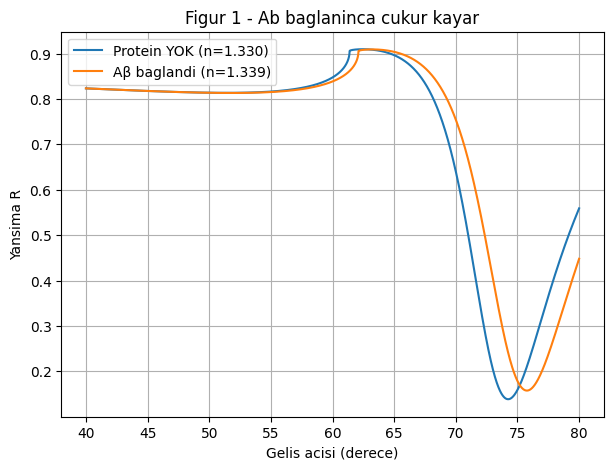

In [ ]:
from tmm import coh_tmm
import numpy as np
import matplotlib.pyplot as plt

N_GRAFEN = 3.0 + 1.149j
KALINLIK = 0.34

def cukur_hesapla(analit_indisi, grafen_katman=0):
    n_list = [1.5151, 0.1726 + 3.4218j]
    d_list = [float('inf'), 50]
    if grafen_katman > 0:
        n_list.append(N_GRAFEN)
        d_list.append(grafen_katman * KALINLIK)
    n_list.append(analit_indisi)
    d_list.append(float('inf'))
    acilar = np.linspace(40, 80, 8000)
    R_listesi = []
    for aci in acilar:
        sonuc = coh_tmm('p', n_list, d_list, np.radians(aci), 633)
        R_listesi.append(sonuc['R'])
    return acilar, R_listesi

# 5 katman grafenli sensor, protein yokken ve varken
acilar, R_yok = cukur_hesapla(1.330, grafen_katman=5)
_,      R_var = cukur_hesapla(1.339, grafen_katman=5)

kayma = acilar[np.argmin(R_var)] - acilar[np.argmin(R_yok)]
print("Kayma:", round(kayma, 3), "derece")

plt.figure(figsize=(7, 5))
plt.plot(acilar, R_yok, label='Protein YOK (n=1.330)')
plt.plot(acilar, R_var, label='Aβ baglandi (n=1.339)')
plt.xlabel('Gelis acisi (derece)')
plt.ylabel('Yansima R')
plt.title('Figur 1 - Ab baglaninca cukur kayar')
plt.legend()
plt.grid(True)
plt.savefig('figur1.png', dpi=150)
plt.show()

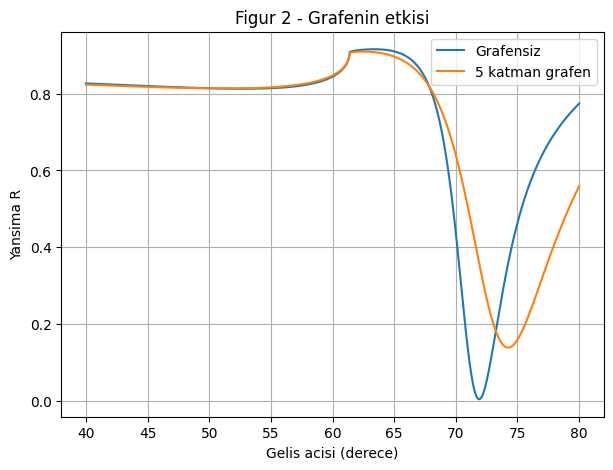

In [ ]:
from tmm import coh_tmm
import numpy as np
import matplotlib.pyplot as plt

N_GRAFEN = 3.0 + 1.149j
KALINLIK = 0.34

def cukur_hesapla(analit_indisi, grafen_katman=0):
    n_list = [1.5151, 0.1726 + 3.4218j]
    d_list = [float('inf'), 50]
    if grafen_katman > 0:
        n_list.append(N_GRAFEN)
        d_list.append(grafen_katman * KALINLIK)
    n_list.append(analit_indisi)
    d_list.append(float('inf'))
    acilar = np.linspace(40, 80, 8000)
    R_listesi = []
    for aci in acilar:
        sonuc = coh_tmm('p', n_list, d_list, np.radians(aci), 633)
        R_listesi.append(sonuc['R'])
    return acilar, R_listesi

# Ikisi de protein yokken: grafensiz vs 5 katman grafen
acilar, R_grafensiz = cukur_hesapla(1.330, grafen_katman=0)
_,      R_grafenli  = cukur_hesapla(1.330, grafen_katman=5)

plt.figure(figsize=(7, 5))
plt.plot(acilar, R_grafensiz, label='Grafensiz')
plt.plot(acilar, R_grafenli,  label='5 katman grafen')
plt.xlabel('Gelis acisi (derece)')
plt.ylabel('Yansima R')
plt.title('Figur 2 - Grafenin etkisi')
plt.legend()
plt.grid(True)
plt.savefig('figur2.png', dpi=150)
plt.show()

Grafen katman: 0  Duyarlilik: 150.0 derece/RIU
Grafen katman: 1  Duyarlilik: 153.9 derece/RIU
Grafen katman: 2  Duyarlilik: 157.2 derece/RIU
Grafen katman: 3  Duyarlilik: 161.7 derece/RIU
Grafen katman: 4  Duyarlilik: 165.6 derece/RIU
Grafen katman: 5  Duyarlilik: 168.9 derece/RIU
Grafen katman: 6  Duyarlilik: 171.7 derece/RIU
Grafen katman: 7  Duyarlilik: 173.9 derece/RIU
Grafen katman: 8  Duyarlilik: 174.5 derece/RIU
Grafen katman: 9  Duyarlilik: 172.2 derece/RIU
Grafen katman: 10  Duyarlilik: 168.4 derece/RIU

EN IYI: 8 katman -> 174.5 derece/RIU


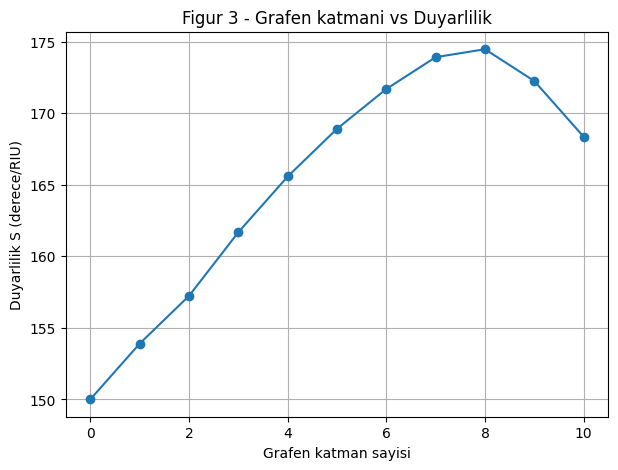

In [ ]:
from tmm import coh_tmm
import numpy as np
import matplotlib.pyplot as plt

N_GRAFEN = 3.0 + 1.149j
KALINLIK = 0.34

def cukur_hesapla(analit_indisi, grafen_katman=0):
    n_list = [1.5151, 0.1726 + 3.4218j]
    d_list = [float('inf'), 50]
    if grafen_katman > 0:
        n_list.append(N_GRAFEN)
        d_list.append(grafen_katman * KALINLIK)
    n_list.append(analit_indisi)
    d_list.append(float('inf'))
    acilar = np.linspace(40, 80, 8000)
    R_listesi = []
    for aci in acilar:
        sonuc = coh_tmm('p', n_list, d_list, np.radians(aci), 633)
        R_listesi.append(sonuc['R'])
    return acilar, R_listesi

def duyarlilik_hesapla(grafen_katman):
    dn = 1.339 - 1.330
    acilar, R_yok = cukur_hesapla(1.330, grafen_katman)
    _,      R_var = cukur_hesapla(1.339, grafen_katman)
    kayma = acilar[np.argmin(R_var)] - acilar[np.argmin(R_yok)]
    return kayma / dn

katmanlar = range(0, 11)
duyarliliklar = []
for N in katmanlar:
    S = duyarlilik_hesapla(N)
    duyarliliklar.append(S)
    print("Grafen katman:", N, " Duyarlilik:", round(S, 1), "derece/RIU")

en_iyi = np.argmax(duyarliliklar)
print("\nEN IYI:", en_iyi, "katman ->", round(duyarliliklar[en_iyi], 1), "derece/RIU")

plt.figure(figsize=(7, 5))
plt.plot(list(katmanlar), duyarliliklar, 'o-')
plt.xlabel('Grafen katman sayisi')
plt.ylabel('Duyarlilik S (derece/RIU)')
plt.title('Figur 3 - Grafen katmani vs Duyarlilik')
plt.grid(True)
plt.savefig('figur3.png', dpi=150)
plt.show()